<a href="https://colab.research.google.com/github/aniilkeles/DeepLearningNotes/blob/main/PyTorch_TrainingSteps_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/06-study_hours_grades.csv')

In [4]:
df.head()

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [6]:
# get data ready
# build model with a training loop and optimizer
# make a prediction with the model
# evaluate the model
# improve the model
# save the model
df.describe()

,study_hours,grade
count,50.000000,50.000000
mean,4.459239,32.290305
std,2.888832,14.431931
min,0.205845,11.032281
25%,1.837670,21.062901
50%,4.360488,31.231858
75%,6.498549,41.683170
max,9.699099,60.573564


In [7]:
df['study_hours'].values

array([3.74540119, 9.50714306, 7.31993942, 5.98658484, 1.5601864 ,
       1.5599452 , 0.58083612, 8.66176146, 6.01115012, 7.08072578,
       0.20584494, 9.69909852, 8.32442641, 2.12339111, 1.81824967,
       1.8340451 , 3.04242243, 5.24756432, 4.31945019, 2.9122914 ,
       6.11852895, 1.39493861, 2.92144649, 3.66361843, 4.56069984,
       7.85175961, 1.99673782, 5.14234438, 5.92414569, 0.46450413,
       6.07544852, 1.70524124, 0.65051593, 9.48885537, 9.65632033,
       8.08397348, 3.04613769, 0.97672114, 6.84233027, 4.40152494,
       1.22038235, 4.9517691 , 0.34388521, 9.09320402, 2.58779982,
       6.62522284, 3.11711076, 5.20068021, 5.46710279, 1.84854456])

In [8]:
type(df['study_hours'].values)

numpy.ndarray

In [9]:
torch.tensor(df['study_hours'].values)

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

In [10]:
y = torch.tensor(df['grade'].values)
X = torch.tensor(df['study_hours'].values)

In [11]:
X

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

In [12]:
y

tensor([30.2039, 57.8785, 46.3684, 39.3307, 14.8439, 16.3600, 11.9829, 55.4231,
        40.7430, 41.8775, 11.6774, 57.7253, 50.2683, 21.8403, 21.1532, 21.0328,
        23.5337, 35.6194, 32.2598, 26.5125, 39.6343, 16.6034, 22.3946, 25.9257,
        34.4286, 51.9713, 19.8397, 37.7188, 40.3440, 11.0323, 41.1000, 21.6023,
        13.1809, 60.5736, 53.0421, 52.0637, 25.4048, 14.2856, 44.3952, 28.0325,
        15.6626, 35.4731, 14.6752, 54.4295, 21.3220, 42.1226, 27.4164, 36.6609,
        36.2760, 20.2693], dtype=torch.float64)

In [13]:
# train-test-split

In [14]:
train_split = int(len(X)*0.80) # bu şekildede train test split yapılabilir sckit learn kütüphanesi kullanılmadan
X_train , y_train = X[:train_split] , y[:train_split]
X_test , y_test = X[train_split:] , y[train_split:]

In [15]:
X_train

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015], dtype=torch.float64)

In [16]:
X_test

tensor([1.2204, 4.9518, 0.3439, 9.0932, 2.5878, 6.6252, 3.1171, 5.2007, 5.4671,
        1.8485], dtype=torch.float64)

In [17]:
y_train

tensor([30.2039, 57.8785, 46.3684, 39.3307, 14.8439, 16.3600, 11.9829, 55.4231,
        40.7430, 41.8775, 11.6774, 57.7253, 50.2683, 21.8403, 21.1532, 21.0328,
        23.5337, 35.6194, 32.2598, 26.5125, 39.6343, 16.6034, 22.3946, 25.9257,
        34.4286, 51.9713, 19.8397, 37.7188, 40.3440, 11.0323, 41.1000, 21.6023,
        13.1809, 60.5736, 53.0421, 52.0637, 25.4048, 14.2856, 44.3952, 28.0325],
       dtype=torch.float64)

In [18]:
y_test

tensor([15.6626, 35.4731, 14.6752, 54.4295, 21.3220, 42.1226, 27.4164, 36.6609,
        36.2760, 20.2693], dtype=torch.float64)

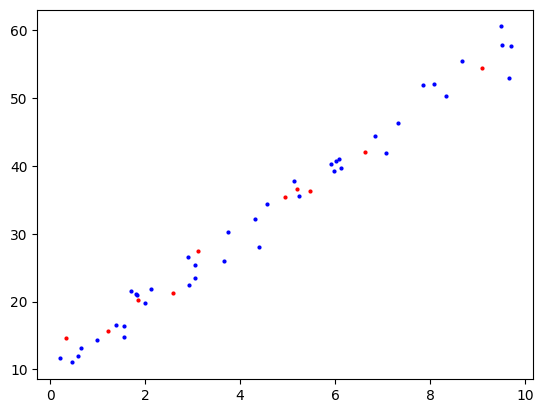

In [19]:
plt.scatter(X_train,y_train,c="b",s=4,label="Training Data")
plt.scatter(X_test,y_test,c="r",s=4,label="Test Data")
plt.show()

In [20]:
# pytorch ann

In [21]:
from torch import nn

class StudyHours(nn.Module):
  def __init__(self):
    super().__init__() ## neural network modelini inheratince alıyor sınıfımız ve initiliazer ya da constructor da diyebiliriz superle üst sınıfımızı çağırmış oluyoruz.
    self.weights = nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True) # öğrenilebilen ekstra bir parametre olarak adlandırılır.requires_grad = true olunca öğrenilebilir parametre onayını veririz.
    self.bias = nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)

  def forward(self,x:torch.Tensor)->torch.Tensor:
    return self.weights*x+self.bias

In [97]:
torch.manual_seed(42)

model_0 = StudyHours()
model_0 = torch.compile(model_0) # torch.compile training aşamasındaki süreci hızlandırmak için kullanılır.

In [98]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [99]:
model_0.state_dict() # içinde bulunduğumuz durumun güncel durumu

OrderedDict([('_orig_mod.weights', tensor([0.3367])),
             ('_orig_mod.bias', tensor([0.1288]))])

In [100]:
with torch.inference_mode(): # eğitim olmadan test datasıyla çalıştığımızı söyleriz.
  y_preds = model_0(X_test)

In [101]:
len(X_test)

10

In [102]:
len(y_preds)

10

In [103]:
len(y_test)

10

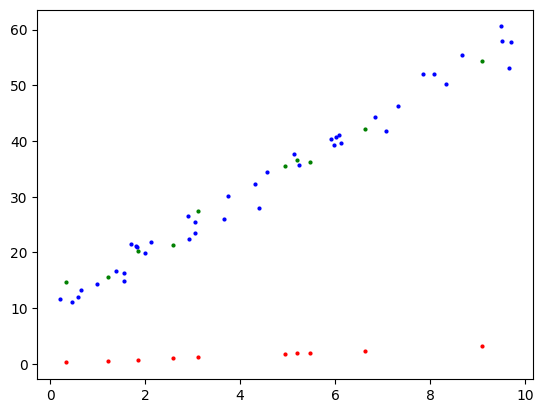

In [104]:
plt.scatter(X_train,y_train,c="b",s=4,label="Training Data")
plt.scatter(X_test,y_test,c="g",s=4,label="Test Data")
plt.scatter(X_test,y_preds,c="r",s=4,label="Test Data")
plt.show()

In [105]:
loss_fn = nn.MSELoss()
#loss_fn = nn.L1Loss() # => MAE
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.001) # lr =0.001

In [106]:
torch.manual_seed(42)
epochs = 120
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
  model_0.train() # train modu

  y_pred = model_0(X_train) # training yaptığımız için X_train verdik
  loss = loss_fn(y_pred,y_train)

  # loss bulunduktan sonra optimizer'la bir back propagation yapılır

  #Model her eğitim adımında gradient (türev) hesaplar.
  #Ama PyTorch’ta gradientler üst üste birikir (accumulate olur).
  #Bu yüzden her yeni adımda eski gradientleri temizlememiz gerekir.
  optimizer.zero_grad() # "Önce eski türevleri temizle
  loss.backward() # model parametrelerine göre türevlerini hesaplar.
  optimizer.step() # gradientleri bildikten sonra ağırlıkları güncelleme zamanı.Yani "Hesaplanan gradientlere göre ağırlıkları güncelle."

  #eğitim bittikten sonra modeli değerlendirme aşamasına alıyoruz
  model_0.eval()

  with torch.inference_mode():
    test_pred = model_0(X_test)

    test_loss = loss_fn(test_pred,y_test) # loss_fn(test_pred,y_test.type(torch.float))
    # sonra grafik çizdirmek için matplotlib numpyla çalıştığından dolayı torchu numpy a çeviririz.

    if epoch %5 ==0:
      epoch_count.append(epoch)
      train_loss_values.append(loss.detach().numpy())
      test_loss_values.append(test_loss.detach().numpy())
      print(f"Epoch : {epoch} , Train Loss : {loss} , Test Loss : {test_loss}")

Epoch : 0 , Train Loss : 1156.0767463081781 , Test Loss : 858.308860146661
Epoch : 5 , Train Loss : 633.9334744710083 , Test Loss : 484.2837829868178
Epoch : 10 , Train Loss : 352.99125276114285 , Test Loss : 280.90521005460033
Epoch : 15 , Train Loss : 201.80191856738534 , Test Loss : 169.8918797355706
Epoch : 20 , Train Loss : 120.41268871324436 , Test Loss : 108.98031233032034
Epoch : 25 , Train Loss : 76.57232180621143 , Test Loss : 75.32370882849361
Epoch : 30 , Train Loss : 52.931428428694815 , Test Loss : 56.55033419714631
Epoch : 35 , Train Loss : 40.157054153236494 , Test Loss : 45.9453113422317
Epoch : 40 , Train Loss : 33.22853631952331 , Test Loss : 39.85291566548663
Epoch : 45 , Train Loss : 29.44509239691046 , Test Loss : 36.27478245490597
Epoch : 50 , Train Loss : 27.353849871049174 , Test Loss : 34.112658291136
Epoch : 55 , Train Loss : 26.173215583708338 , Test Loss : 32.758721543163134
Epoch : 60 , Train Loss : 25.48277112837836 , Test Loss : 31.873637954658694
Epoch 

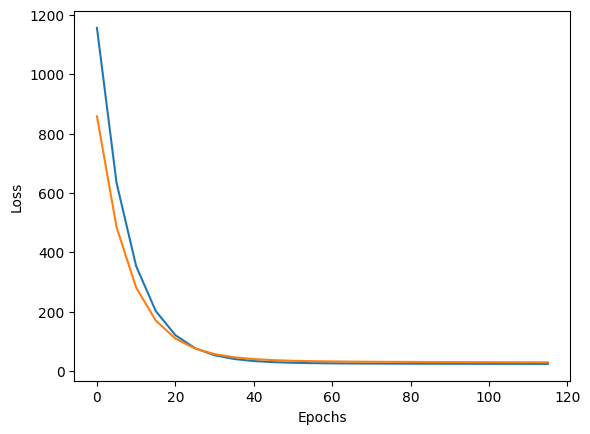

In [107]:
plt.plot(epoch_count,train_loss_values,label="Train Loss")
plt.plot(epoch_count,test_loss_values,label="Test Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.show()

In [108]:
model_0.state_dict()

OrderedDict([('_orig_mod.weights', tensor([6.2983])),
             ('_orig_mod.bias', tensor([1.6607]))])

In [109]:
model_0.eval()
with torch.inference_mode():
  y_preds = model_0(X_test)

In [110]:
X_test

tensor([1.2204, 4.9518, 0.3439, 9.0932, 2.5878, 6.6252, 3.1171, 5.2007, 5.4671,
        1.8485], dtype=torch.float64)

In [111]:
y_preds

tensor([ 9.3471, 32.8485,  3.8266, 58.9326, 17.9595, 43.3885, 21.2933, 34.4162,
        36.0943, 13.3034], dtype=torch.float64)

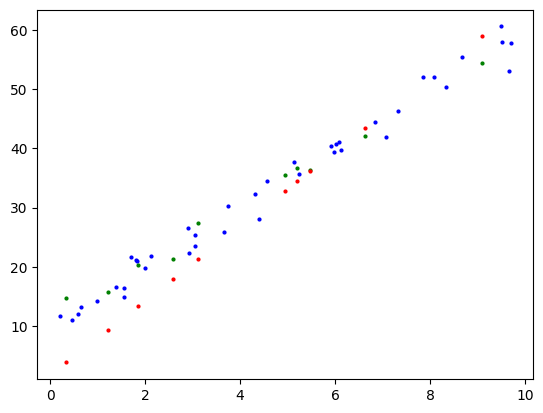

In [112]:
plt.scatter(X_train,y_train,c="b",s=4,label="Training Data")
plt.scatter(X_test,y_test,c="g",s=4,label="Test Data")
plt.scatter(X_test,y_preds,c="r",s=4,label="Predictions")
plt.show()